**Connect Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Install YOLO**

In [3]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.6 MB/s eta 0:00:00


**Dataset Extract**

In [4]:
import zipfile

zip_path = "/content/uno_dataset_final.zip"
extract_path = "/content/uno_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extracted")

✅ Extracted


**Images & label path**

In [5]:
import os

image_dir = None
label_dir = None

for root, dirs, files in os.walk(extract_path):
    if "images" in root:
        image_dir = root
    if "labels" in root:
        label_dir = root

print("Images:", image_dir)
print("Labels:", label_dir)

Images: /content/uno_dataset/UNO game card Recognation/images
Labels: /content/uno_dataset/UNO game card Recognation/labels


**Class Name load & make data.yaml**

In [6]:
import os

class_file_path = os.path.join(label_dir, "classes.txt")

names = []
if os.path.exists(class_file_path):
    with open(class_file_path, "r") as f:
        names = f.read().splitlines()
else:
    # If classes.txt is not found, attempt to infer class IDs from label files
    print("WARNING: classes.txt not found. Attempting to infer class names from label files.")
    unique_class_ids = set()
    label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]

    for label_fname in label_files:
        label_full_path = os.path.join(label_dir, label_fname)
        try:
            with open(label_full_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        class_id = int(parts[0])
                        unique_class_ids.add(class_id)
        except Exception as e:
            print(f"Error reading label file {label_full_path}: {e}")

    if unique_class_ids:
        max_class_id = max(unique_class_ids)
        names = [f"class_{i}" for i in range(max_class_id + 1)]
        print(f"Inferred {len(names)} class names: {names}")
    else:
        print("No class IDs found in label files. Setting a generic placeholder name.")
        # Fallback to a single generic class if no class IDs are found at all
        names = ["object"]

nc = len(names)

yaml_content = f"""
train: {image_dir}
val: {image_dir}

nc: {nc}
names: {names}
"""

with open("/content/data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ data.yaml ready")

✅ data.yaml ready


**Model save to drive**

In [7]:
save_dir = "/content/drive/MyDrive/UNO_YOLO_Model"

**Model Load & traning start**

In [8]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/data.yaml",
    epochs=120,
    imgsz=640,
    batch=8,
    patience=25,
    project="/content/drive/MyDrive/UNO_YOLO_Model",
    name="uno_model"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, i

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78e80cc89070>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.03303

**Best Model save to drive**

In [9]:
import shutil

src = "/content/drive/MyDrive/UNO_YOLO_Model/uno_model-3/weights/best.pt"
dst = "/content/drive/MyDrive/UNO_best_model.pt"

shutil.copy(src, dst)

print("✅ Model saved to Drive root")

✅ Model saved to Drive root


**YOLO model weight backup to google drive**

In [10]:
import shutil

base = "/content/drive/MyDrive/UNO_YOLO_Model/uno_model-3/weights"

shutil.copy(base + "/best.pt", "/content/drive/MyDrive/UNO_best.pt")
shutil.copy(base + "/last.pt", "/content/drive/MyDrive/UNO_last.pt")

print("✅ Both models saved")

✅ Both models saved


**Loading trained YOLO model from save weight**

In [11]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/UNO_YOLO_Model/uno_model-3/weights/best.pt")

**UNO Card Detection Using Trained YOLO Model with Image Upload and Inference**

Saving WhatsApp Image 2026-04-21 at 9.40.15 PM.jpeg to WhatsApp Image 2026-04-21 at 9.40.15 PM.jpeg
📤 Uploaded Image: WhatsApp Image 2026-04-21 at 9.40.15 PM.jpeg

image 1/1 /content/WhatsApp Image 2026-04-21 at 9.40.15 PM.jpeg: 640x480 1 class_37, 9.1ms
Speed: 7.9ms preprocess, 9.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)

🎯 Detection Results:
----------------------------------------
🃏 Class: red_skip
🎯 Confidence: 33.08%
----------------------------------------


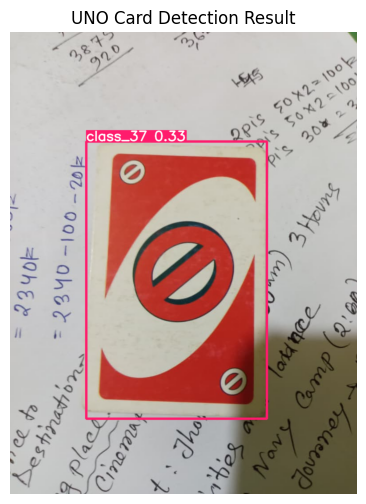

In [15]:
from ultralytics import YOLO
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# =========================
# 1. Load trained model
# =========================
model = YOLO("/content/drive/MyDrive/UNO_YOLO_Model/uno_model-3/weights/best.pt")

# The model's class names are already loaded correctly into results[0].names.
# Attempting to assign 'model.names = names' causes an AttributeError.
# Therefore, this line is removed.

# =========================
# 2. Upload image from user
# =========================
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

print("📤 Uploaded Image:", img_path)

# =========================
# 3. Run prediction
# =========================
results = model.predict(source=img_path, conf=0.25)

# =========================
# 4. Print detailed results
# =========================
print("\n🎯 Detection Results:")
print("-" * 40)

if len(results[0].boxes) == 0:
    print("❌ No UNO card detected")
else:
    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        # Use the 'names' variable from the kernel state for accurate class names
        class_name = names[cls_id]

        print(f"🃏 Class: {class_name}")
        print(f"🎯 Confidence: {round(conf * 100, 2)}%")
        print("-" * 40)

# =========================
# 5. Show image with detection
# =========================
annotated_img = results[0].plot()

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("UNO Card Detection Result")
plt.show()